# Figure 1
Figure 1: 
a) Schematic of the task
b) Train loss vs. # of parameters for GPT for Zipfian distribution
c) Max learned rank vs. params


## 1a: Visualize sequences

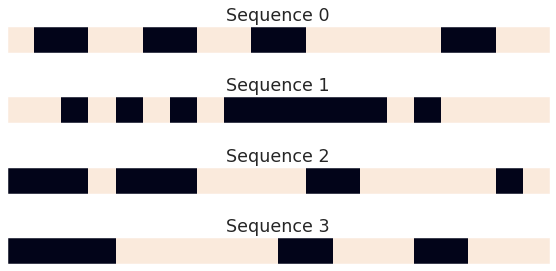

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import utils
import os
from collections import defaultdict
sns.set(
    context='talk', 
font_scale=1.0,
# font = "Arial",
color_codes=True, 
palette='deep',
#  style='ticks', 
 rc={"patch.edgecolor": "none", 
 'mathtext.fontset': 'cm', 
 'xtick.direction': 'in',
 'ytick.direction': 'in', 
 'axes.linewidth': 1.5, 
 'figure.dpi':70, 
'text.usetex':False , 
'font.size':24}
)
fig, axs = plt.subplots(4, 1, figsize=(10, 5))
# no ticks 
for i, ax in enumerate(axs):
    ax.imshow(np.random.choice([0, 1], size=(1, 20)))
    ax.set_title(f"Sequence {i}")
    ax.set_xticks([])
    ax.set_yticks([])
savefigdir = "./figs/Figure1"
out = f"{savefigdir}/Figure1a_sequences_visualization"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()


## 1b & 1c: Visualize Zipf distribution

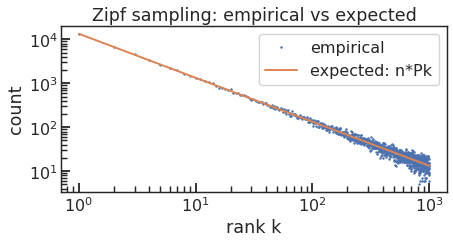

In [7]:
import numpy as np
import matplotlib.pyplot as plt
sns.set(context='talk', font_scale=1.0,
# font = "Arial",
color_codes=True, palette='deep', style='ticks', rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in', 'axes.linewidth': 1.5, 'figure.dpi':70, 
'text.usetex':False , 'font.size':24})
K = 1000
Pk = 1.0 / np.arange(1, K+1)
Pk = Pk / Pk.sum()

n = 100000
samples = np.random.choice(np.arange(1, K+1), size=n, p=Pk)  # ranks 1..K
counts = np.bincount(samples, minlength=K+1)[1:]             # drop 0 bin

ranks = np.arange(1, K+1)
expected = n * Pk

mask = counts > 0  # avoid log(0)

plt.figure(figsize=(7,4))
plt.loglog(ranks[mask], counts[mask], '.', ms=3, label="empirical")
plt.loglog(ranks, expected, '-', lw=2, label="expected: n*Pk")
plt.xlabel("rank k")
plt.ylabel("count")
plt.title("Zipf sampling: empirical vs expected")
plt.legend()
plt.tight_layout()

savefigdir = "./figs/Figure1"
out = f"{savefigdir}/Figure1b_zipf_distribution"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


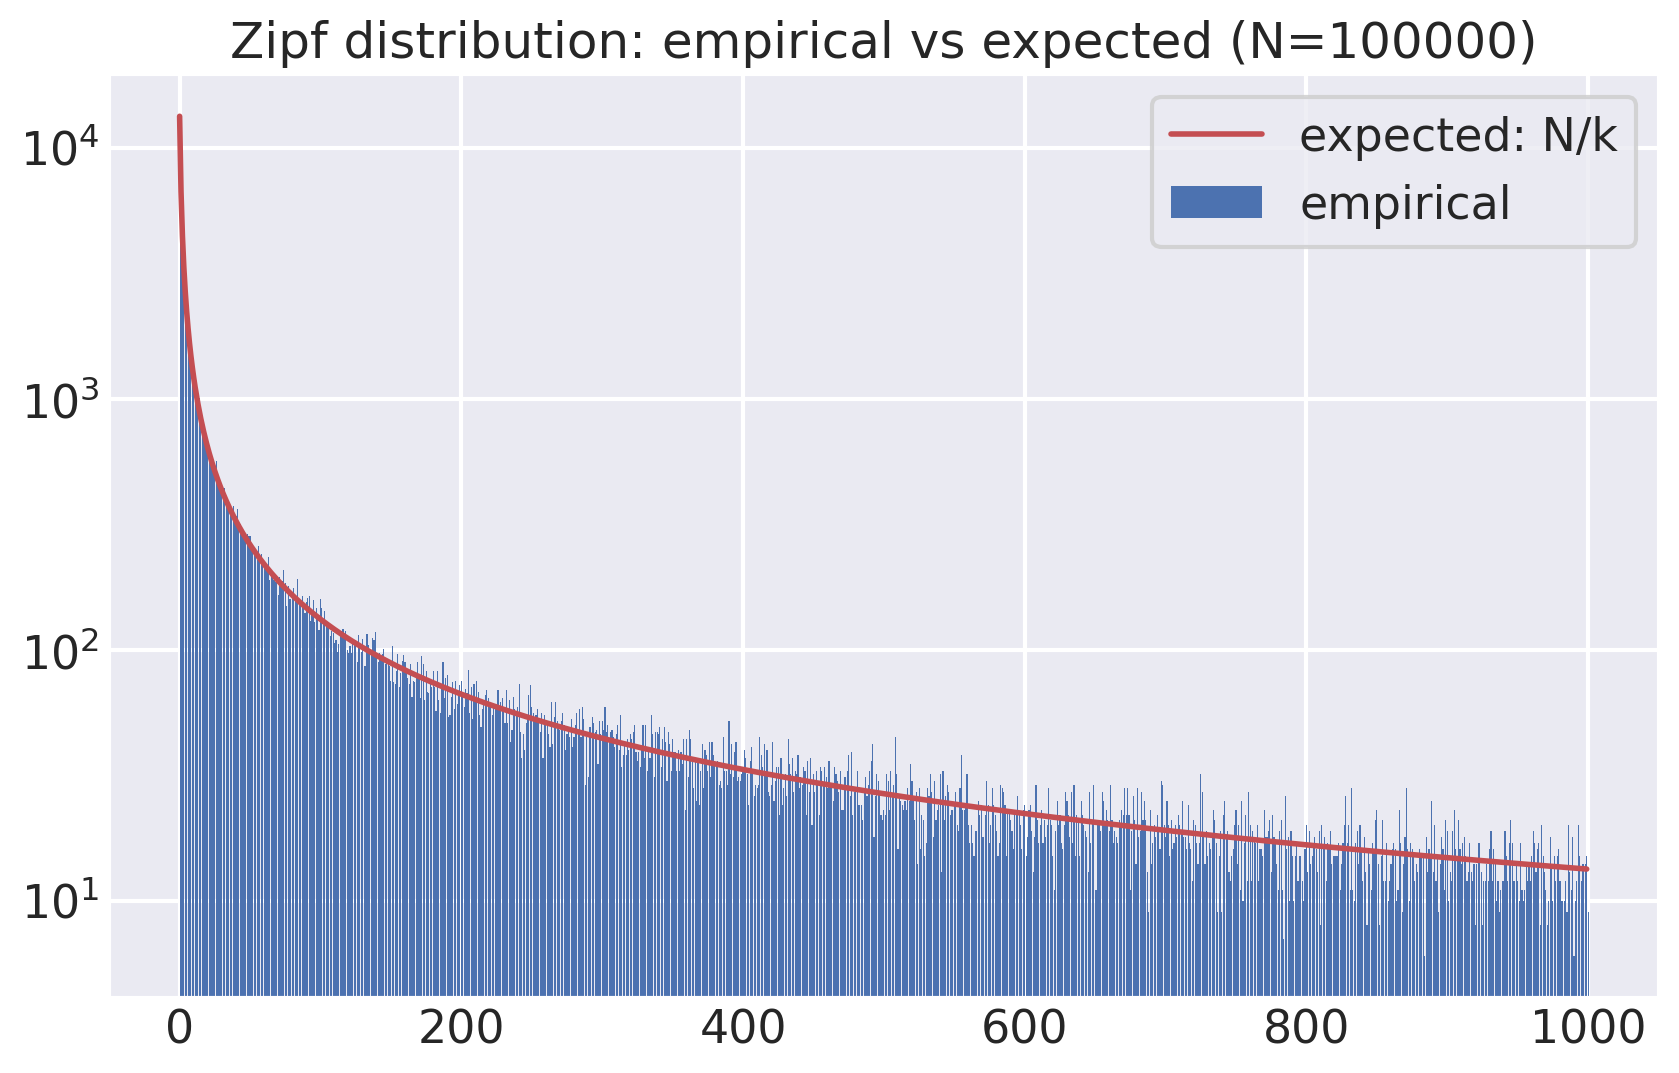

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# mpl.rcParams["patch.edgecolor"], mpl.rcParams.get("patch.force_edgecolor", None)
sns.set(
    context='talk', 
font_scale=1.0,
# font = "Arial",
color_codes=True, 
palette='deep',
#  style='ticks', 
 rc={"patch.edgecolor": "none", 
 'mathtext.fontset': 'cm', 
 'xtick.direction': 'in',
 'ytick.direction': 'in', 
 'axes.linewidth': 1.5, 
 'figure.dpi':70, 
'text.usetex':False , 
'font.size':24}
)
K = 1000
Pk = 1.0 / np.arange(1, K+1)
Pk = Pk / Pk.sum()

n = 100000
ranks = np.arange(1, K+1)

samples = np.random.choice(ranks, size=n, p=Pk)
counts = np.bincount(samples, minlength=K+1)[1:]   # counts for ranks 1..K  
expected = n * Pk
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)  # override the global rc dpi
ax.bar(np.arange(1,K+1), counts, label="empirical", color="C0")
ax.plot(np.arange(K), expected, "r", lw=2, label="expected: N/k")
ax.set_yscale("log")
plt.title("Zipf distribution: empirical vs expected (N=100000)")
ax.legend()
savefigdir = "./figs/Figure1"
out = f"{savefigdir}/Figure1c_zipf_distribution"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()


## 1d: Train loss vs. # of parameters for GPT for Zipfian distribution, No resampling

In [12]:
import pickle 
from glob import glob 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import utils
from collections import defaultdict



In [13]:
folders = glob("/scratch/qanguyen/gautam/cache/memo_nov10_zipf_gpt2_vary_num_hidden_features_num_heads_noresample/*")
df = defaultdict(list)
for folder in folders:
    pkl = glob(f"{folder}/*")
    run_name = pkl[0].split("/")[-1] 
    fname = f"{folder}/{run_name}"
    with open(fname, "rb") as f:
        data = utils.CPU_Unpickler(f).load()
    if "logs" not in data:
        continue
    if len(data['logs']) < 80: 
        continue
    num_parameters = sum(p.numel() for k, p in data["model"].items())
    # print("positional_encoding", data["positional_encoding"].shape)
    
    
    logs = data["logs"][0]
    train_losses = [l["train_loss"] for l in data["logs"]] 
    num_hidden_features = data["args"]["num_hidden_features"]
    num_heads = data["args"]["num_heads"]
    accuracy = data["logs"][-1]["test_metrics"]["accuracy"][:100].mean() 
    if num_parameters > 1e6 and train_losses[-1] > 0.3: 
        failed=True 
    else: 
        failed=False 
    # plt.imshow(np.corrcoef(data["positional_encoding"]),vmin=0)
    # plt.title(f"Corrcoef Positional Encoding for head {num_heads}, hidden features {num_hidden_features}")
    # plt.show()
    print("len(data['logs'])", len(data["logs"]), "arch", data["args"]["arch"], "num_parameters", num_parameters, "num_layers", data["args"]["num_layers"], "num_heads", data["args"]["num_heads"], "num_hidden_features", data["args"]["num_hidden_features"], "accuracy", accuracy)
    df["train_loss"].extend(train_losses)
    df["test_accuracy"].extend([accuracy] * len(train_losses))
    df["num_parameters"].extend([num_parameters] * len(train_losses))
    df["num_hidden_features"].extend([num_hidden_features] * len(train_losses))
    df["num_heads"].extend([num_heads] * len(train_losses))
    df["epoch"].extend(range(len(train_losses)))
    df["failed"].extend([failed] * len(train_losses))
    # df = pd.read_csv(f"{folder}/eval_results.csv")
    # print(df.head())


len(data['logs']) 80 arch gpt num_parameters 155842 num_layers 12 num_heads 4 num_hidden_features 8 accuracy 0.7196971
len(data['logs']) 80 arch gpt num_parameters 3728322 num_layers 12 num_heads 10 num_hidden_features 16 accuracy 0.9548484
len(data['logs']) 80 arch gpt num_parameters 2392834 num_layers 12 num_heads 2 num_hidden_features 64 accuracy 0.50737375
len(data['logs']) 80 arch gpt num_parameters 9504258 num_layers 12 num_heads 8 num_hidden_features 32 accuracy 0.49979797
len(data['logs']) 80 arch gpt num_parameters 155842 num_layers 12 num_heads 8 num_hidden_features 4 accuracy 0.64666665
len(data['logs']) 80 arch gpt num_parameters 21334274 num_layers 12 num_heads 12 num_hidden_features 32 accuracy 0.50414145
len(data['logs']) 80 arch gpt num_parameters 1352258 num_layers 12 num_heads 6 num_hidden_features 16 accuracy 0.95181817
len(data['logs']) 80 arch gpt num_parameters 89234 num_layers 12 num_heads 12 num_hidden_features 2 accuracy 0.64909095
len(data['logs']) 80 arch gpt

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


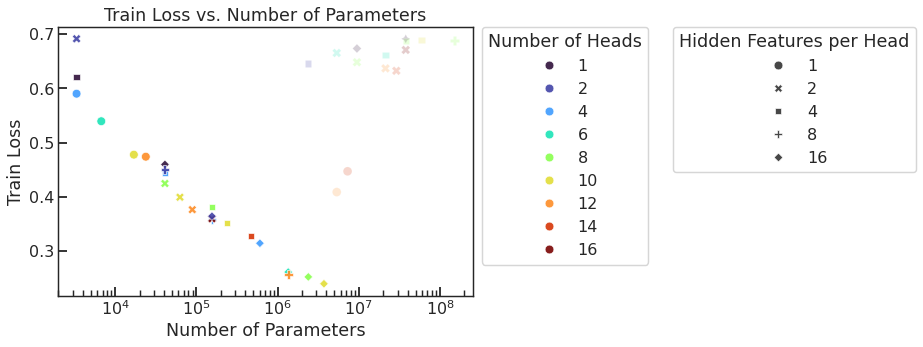

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


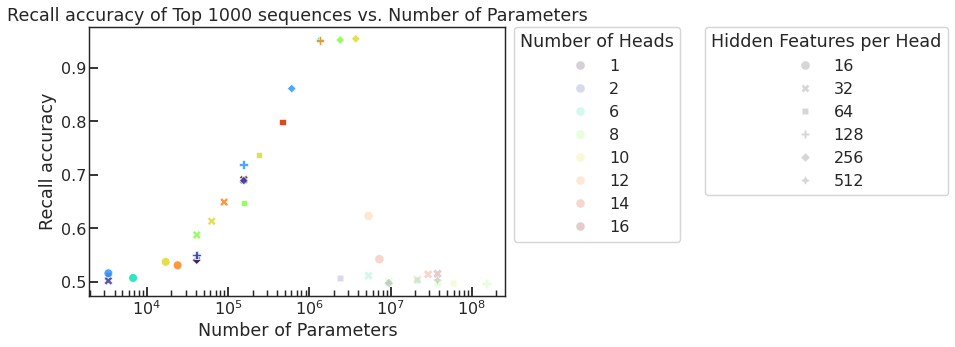

In [ ]:
sns.set(context='talk', font_scale=1.0,
# font = "Arial",
color_codes=True, palette='deep', style='ticks', rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in', 'axes.linewidth': 1.5, 'figure.dpi':70, 
'text.usetex':False , 'font.size':24})

_df = pd.DataFrame(df)
_df = _df[_df["epoch"] == 79]
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
failed = _df[_df["failed"] == True]
ok = _df[_df["failed"] == False]

# more transparent (lower alpha) for failed
sns.scatterplot(
    data=failed,
    x="num_parameters", y="train_loss",
    hue="num_heads", style="num_hidden_features",
    palette="turbo",
    alpha=0.2,
    legend=False,
    ax=ax,
)

# less transparent for non-failed
sns.scatterplot(
    data=ok,
    x="num_parameters", y="train_loss",
    hue="num_heads", style="num_hidden_features",
    palette="turbo",
    alpha=0.9,
    legend="full",   # don't duplicate legend
    ax=ax,
)

ax.set_title("Train Loss vs. Number of Parameters")
ax.set_xlabel("Number of Parameters")
ax.set_xscale("log")
ax.set_ylabel("Train Loss")

# grab seaborn's combined legend entries, then remove it
handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()

# split at the "num_hidden_features" header
i = labels.index("num_hidden_features")
h_hue, l_hue = handles[1:i], labels[1:i]
h_style, l_style = handles[i+1:], labels[i+1:]

# make room on the right for TWO legend boxes
fig.subplots_adjust(right=0.62)

# legend 1 (left of the pair)
leg1 = ax.legend(
    h_hue, l_hue,
    title="Number of Heads",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
)
ax.add_artist(leg1)

# legend 2 (to the right of legend 1)
ax.legend(
    h_style, l_style,
    title="Hidden Features per Head",
    loc="upper left",
    bbox_to_anchor=(1.48, 1.0),  # increase x to move further right
    borderaxespad=0.0,
)
savefigdir = "./figs/Figure1"
out = f"{savefigdir}/Figure1d_zipf_distribution_train_loss_vs_num_parameters"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()

plt.show()
 
# Show Recall accuracy vs num_heads and num_hidden_features
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# more transparent (lower alpha) for failed
sns.scatterplot(
    data=failed,
    x="num_parameters", y="test_accuracy",
    hue="num_heads", style="num_hidden_features",
    palette="turbo",
    alpha=0.2,
    legend="full",
    ax=ax,
)

# less transparent for non-failed
sns.scatterplot(
    data=ok,
    x="num_parameters", y="test_accuracy",
    hue="num_heads", style="num_hidden_features",
    palette="turbo",
    alpha=0.9,
    legend=False,   # don't duplicate legend
    ax=ax,
)

ax.set_title("Recall accuracy of Top 1000 sequences vs. Number of Parameters")
ax.set_xlabel("Number of Parameters")
ax.set_xscale("log")
ax.set_ylabel("Recall accuracy")

# grab seaborn's combined legend entries, then remove it
handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()

# split at the "num_hidden_features" header
i = labels.index("num_hidden_features")
h_hue, l_hue = handles[1:i], labels[1:i]
h_style, l_style = handles[i+1:], labels[i+1:]

# make room on the right for TWO legend boxes
fig.subplots_adjust(right=0.62)

# legend 1 (left of the pair)
leg1 = ax.legend(
    h_hue, l_hue,
    title="Number of Heads",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
)
ax.add_artist(leg1)

# legend 2 (to the right of legend 1)
ax.legend(
    h_style, l_style,
    title="Hidden Features per Head",
    loc="upper left",
    bbox_to_anchor=(1.48, 1.0),  # increase x to move further right
    borderaxespad=0.0,
)
savefigdir = "./figs/Figure1"
out = f"{savefigdir}/Figure1e_zipf_distribution_recall_accuracy_vs_num_parameters"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()
 

## S1a: Train loss vs. epoch / num heads / num hidden features

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


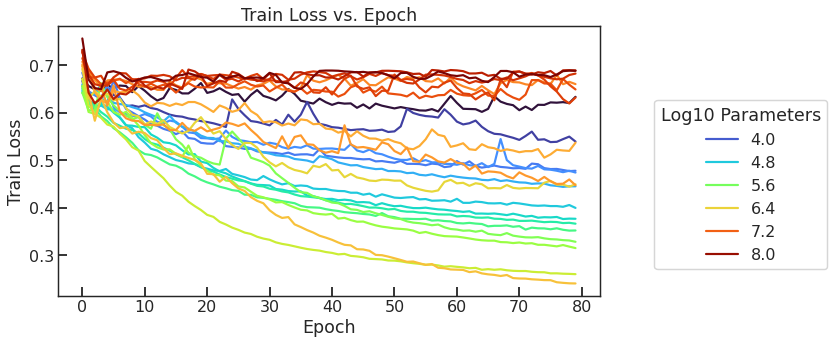

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


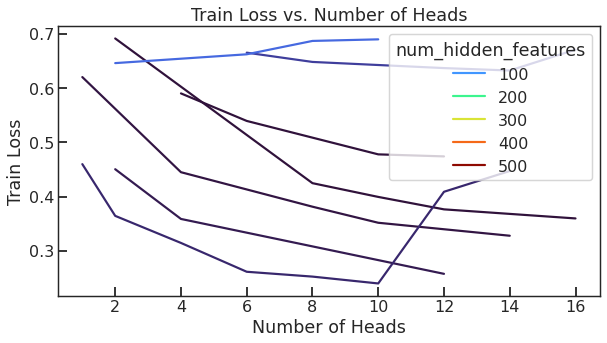

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


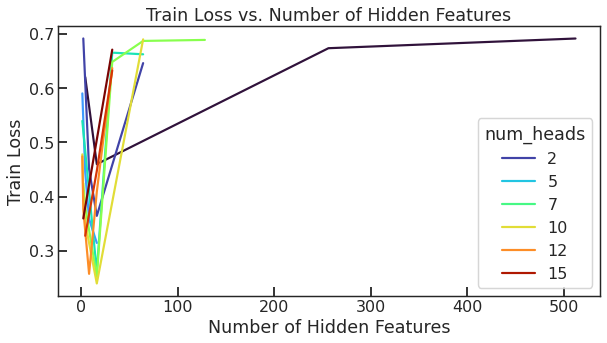

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


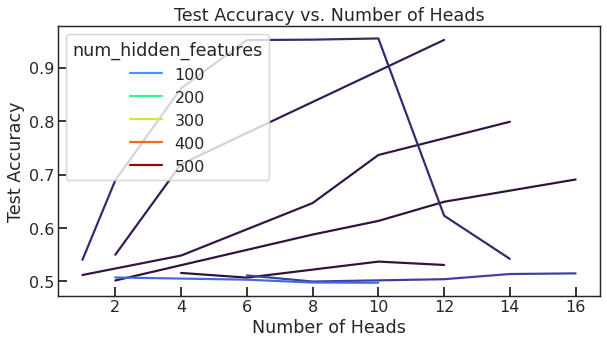

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


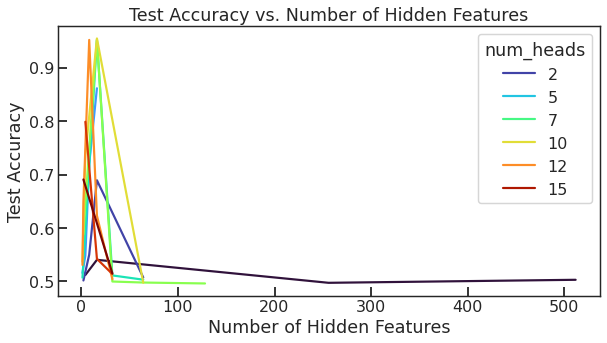

In [19]:

fig, ax = plt.subplots(1, 1, figsize=(10, 5)) 
df["log_num_parameters"] = np.log10(df["num_parameters"])
sns.lineplot(x="epoch", y="train_loss", data=df, hue="log_num_parameters", palette="turbo", errorbar=None)
plt.title(f"Train Loss vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.legend(loc=(1.1,0.1), title="Log10 Parameters")
savefigdir = "./figs/SupplementalFigure1"
out = f"{savefigdir}/S1a_train_loss_vs_epoch"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()


fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x="num_heads", y="train_loss", hue = "num_hidden_features", data=_df, palette="turbo")
plt.title(f"Train Loss vs. Number of Heads")
plt.xlabel("Number of Heads")
# plt.xscale("log")
plt.ylabel("Train Loss")
savefigdir = "./figs/SupplementalFigure1"
out = f"{savefigdir}/S1b_train_loss_vs_num_heads"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x="num_hidden_features", y="train_loss", hue="num_heads", data=_df, palette="turbo")
plt.title(f"Train Loss vs. Number of Hidden Features")
plt.xlabel("Number of Hidden Features")
# plt.xscale("log")
plt.ylabel("Train Loss")
savefigdir = "./figs/SupplementalFigure1"
out = f"{savefigdir}/S1c_train_loss_vs_num_hidden_features"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Test accuracy 
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x="num_heads", y="test_accuracy", hue = "num_hidden_features", data=_df, palette="turbo")
plt.title(f"Test Accuracy vs. Number of Heads")
plt.xlabel("Number of Heads")
# plt.xscale("log")
plt.ylabel("Test Accuracy")
savefigdir = "./figs/SupplementalFigure1"
out = f"{savefigdir}/S1d_test_accuracy_vs_num_heads"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(x="num_hidden_features", y="test_accuracy", hue="num_heads", data=_df, palette="turbo")
plt.title(f"Test Accuracy vs. Number of Hidden Features")
plt.xlabel("Number of Hidden Features")
# plt.xscale("log")
plt.ylabel("Test Accuracy")
savefigdir = "./figs/SupplementalFigure1"
out = f"{savefigdir}/S1e_test_accuracy_vs_num_hidden_features"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show() 


## S2: Train loss vs. # of parameters for GPT for uniform distribution


In [1]:
import pickle 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import utils
from collections import defaultdict
from glob import glob
sns.set(context='talk', font_scale=1.0,
# font = "Arial",
color_codes=True, palette='deep', style='ticks', rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in', 'axes.linewidth': 1.5, 'figure.dpi':70, 
'text.usetex':False , 'font.size':24})

# fname = './cache/memo_may10_zipf_onelayerattention_lr_1e-3/memo_may10_zipf_onelayerattention_lr_1e-3_transformer_K_1000_L_100_hidden_8_nheads_20_nlayers_4_1746999806.3694336/memo_may10_zipf_onelayerattention_lr_1e-3_transformer_K_1000_L_100_hidden_8_nheads_20_nlayers_4_1746999806.3694336.pkl' 
# f = './cache/memo_june28_fork_progress/*'
f = '/scratch/qanguyen/gautam/cache/memo_jan14_uniformdist_modelsize/*'
df = defaultdict(list)
folders = glob(f) 
print(len(folders))
for folder in folders:
    
    subdir = folder.split('/')[-1]
    fname = folder + '/' + subdir + '.pkl'
    try:
        with open(fname, 
                'rb') as f:
            data = utils.CPU_Unpickler(f).load()
        
    except Exception as e:
        continue
    print("args", data["args"])
    print(data.keys())
    # plot train loss
    # fig, axs = plt.subplots(1, 1, figsize=(5, 6))
    # num_iters_per_epoch = 1000
    # axs.plot(np.arange(0,len(data["logs"])*num_iters_per_epoch,num_iters_per_epoch), [i["train_loss"] for i in data["logs"]])

    # plt.plot([i["train_loss"] for i in data["logs"]])
    # plt.show()
    num_heads = data["args"]["num_heads"]
    num_layers = data["args"]["num_layers"]   
    num_parameters = np.sum([torch.prod(torch.tensor(v.shape)).item() for k, v in data["model"].items()])
    print("model", data["args"]["lr"], num_heads, num_layers,
            "K", data["args"]["K"],
          "len logs", len(data["logs"]), "epochs", (data["logs"][-1]["epoch"]+1)*50, 
          "is_resample_tasks", data["args"]["is_resample_tasks"]) 
    if len(data["logs"]) < 100: 
        continue 
    print("keys", data["logs"][-1].keys()) 
    train_losses = data["logs"][-1]["train_loss"] 
    test_accuracy = data["logs"][-1]["test_metrics"]["accuracy"].mean()
    
    df["num_heads"].append(int(num_heads))
    df["num_layers"].append(int(num_layers))
    df["num_parameters"].append(num_parameters)
    df["train_losses"].append(train_losses) 
    df["test_accuracy"].append(test_accuracy)

/tmp/ipykernel_2519023/1536201598.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


143
args {'data': './cache', 'cache': './cache', 'wandb_log': False, 'wandb_project': 'l2l', 'wandb_group_name': 'memo_jan14_uniformdist_modelsize', 'seed': 8815000, 'num_iters_per_epoch': 1000, 'num_iters': 100000, 'batch_size': 256, 'workers': 4, 'optimizer': 'Adam', 'lr': 0.001, 'momentum': 0.9, 'weight_decay': 0.0, 'arch': 'gpt', 'gpt_bias': 'True', 'is_initialize_attention_weights_to_zero': 'False', 'num_hidden_features': 8, 'num_layers': 4, 'num_heads': 1, 'num_mlp_layers': 3, 'len_context': 100, 'SLURM_ARRAY_TASK_ID': 36, 'no_cuda': False, 'K': 20000, 'sequence_sampling_distribution': 'uniform', 'is_resample_tasks': 'False', 'fileprefix': 'transformer', 'savedir': '/scratch/qanguyen/gautam', 'resume': None, 'vocab_size': 2}
dict_keys(['args', 'logs', 'model', 'positional_encoding', 'token_embedding'])
model 0.001 1 4 K 20000 len logs 100 epochs 5000 is_resample_tasks False
keys dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'tes

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


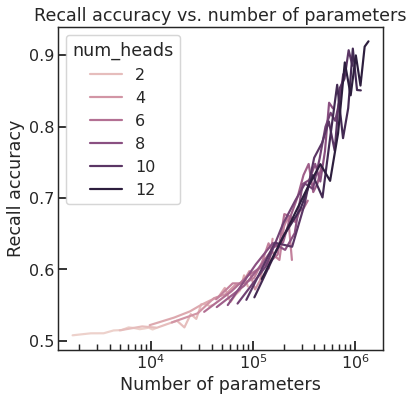

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


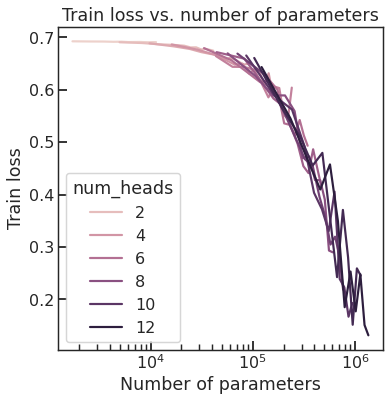

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6)) 
sns.lineplot(x="num_parameters", y="test_accuracy", hue="num_heads", data=df)
plt.xscale("log")
plt.xlabel("Number of parameters")
plt.ylabel("Recall accuracy")
plt.title("Recall accuracy vs. number of parameters")
savefigdir = "./figs/SupplementalFigure2"
out = f"{savefigdir}/S2a_recall_accuracy_vs_num_parameters"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(6, 6)) 
sns.lineplot(x="num_parameters", y="train_losses", hue="num_heads", data=df)
plt.xscale("log")
plt.xlabel("Number of parameters")
plt.ylabel("Train loss")
plt.title("Train loss vs. number of parameters")
savefigdir = "./figs/SupplementalFigure2"
out = f"{savefigdir}/S2b_train_loss_vs_num_parameters"
utils.ensure_dir(savefigdir)
fig.savefig(f"{out}.eps", format="eps", bbox_inches="tight")
fig.savefig(f"{out}.pdf", format="pdf", bbox_inches="tight")
plt.show()






,num_heads,num_layers,num_parameters,train_losses,test_accuracy
0,1,4,4338,0.691503,0.514556
1,12,1,122018,0.643306,0.586596
2,4,10,130434,0.608120,0.615192
3,6,3,89906,0.632228,0.591606
4,9,12,765362,0.218673,0.873369
...,...,...,...,...,...
138,6,5,146450,0.617554,0.610768
139,12,6,681218,0.349283,0.790535
140,3,6,45890,0.666192,0.561111
141,8,1,56770,0.669508,0.550121


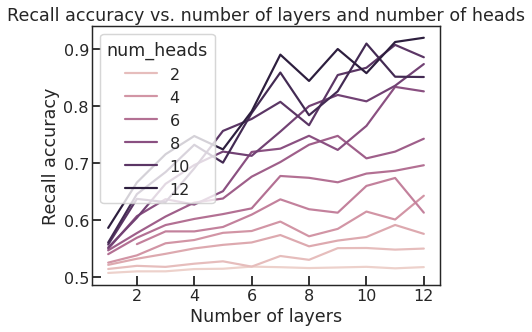

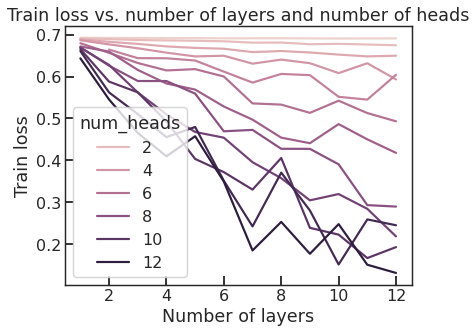

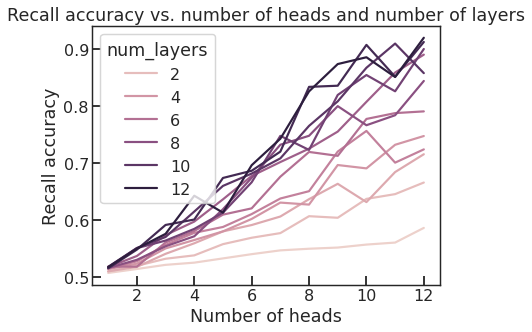

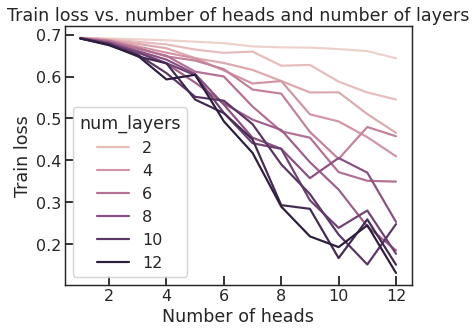

In [4]:
df = pd.DataFrame(df)
display(df)
sns.lineplot(x="num_layers", y="test_accuracy", hue="num_heads", data=df)
plt.xlabel("Number of layers")
plt.ylabel("Recall accuracy")
plt.title("Recall accuracy vs. number of layers and number of heads")
plt.show()
sns.lineplot(x="num_layers", y="train_losses", hue="num_heads", data=df)
plt.xlabel("Number of layers")
plt.ylabel("Train loss")
plt.title("Train loss vs. number of layers and number of heads")
plt.show()

sns.lineplot(x="num_heads", y="test_accuracy", hue="num_layers", data=df)
plt.xlabel("Number of heads")
plt.ylabel("Recall accuracy")
plt.title("Recall accuracy vs. number of heads and number of layers")
plt.show()
sns.lineplot(x="num_heads", y="train_losses", hue="num_layers", data=df)
plt.xlabel("Number of heads")
plt.ylabel("Train loss")
plt.title("Train loss vs. number of heads and number of layers")
plt.show()


# Figure 2

1 panel: appearances before saturation

In [1]:
import pickle 
from glob import glob 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import utils
from collections import defaultdict

sns.set(context='talk', font_scale=1.0,
# font = "Arial",
color_codes=True, palette='deep', style='ticks', rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in', 'axes.linewidth': 1.5, 'figure.dpi':70, 
'text.usetex':False , 'font.size':24})

/tmp/ipykernel_4157057/2178422424.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [34]:
from scipy.optimize import curve_fit

folders = glob("/scratch/qanguyen/gautam/cache/memo_nov10_zipf_gpt2_vary_num_hidden_features_num_heads_noresample/*")
df = defaultdict(list)
df_capacity = defaultdict(list)
# Reverse sigmoid (decreasing logistic): high -> low
def rev_sigmoid(x, y_low, y_high, x0, k):
    # k > 0; transition centered at x0
    return y_low + (y_high - y_low) / (1.0 + np.exp((x - x0) / k))

for folder in folders:
    pkl = glob(f"{folder}/*")
    run_name = pkl[0].split("/")[-1] 
    fname = f"{folder}/{run_name}"
    with open(fname, "rb") as f:
        data = utils.CPU_Unpickler(f).load()
    if "logs" not in data:
        continue
    num_parameters = sum(p.numel() for k, p in data["model"].items())
    print("len(data['logs'])", len(data["logs"]), "key", data["logs"][0].keys(), "num_parameters", num_parameters, "num_layers", data["args"]["num_layers"], "num_heads", data["args"]["num_heads"], "num_hidden_features", data["args"]["num_hidden_features"])
    if num_parameters > 1e6 and data["logs"][-1]["train_loss"] > 0.3:
        continue
    if len(data["logs"]) < 80:
        continue
    num_hidden_features = data["args"]["num_hidden_features"]
    num_heads = data["args"]["num_heads"] 
    num_appearances_at_39 = None
    for l in data["logs"]:
        num_appearances = l["num_apppearances"][::10]
        
        test_metrics = l["test_metrics"]
        sequence_ranks = test_metrics["sequence_rank"] * 10
        accuracy = test_metrics["accuracy"] 
        if num_appearances_at_39 is not None:
            num_appearances -= num_appearances_at_39
        df["num_appearances"].extend(num_appearances)
        df["sequence_rank"].extend(sequence_ranks)
        df["accuracy"].extend(accuracy)
        df["num_parameters"].extend([ num_parameters ] * len(num_appearances))
        df["epoch"].extend([l["epoch"]] * len(num_appearances))   
        switch_number = int (l["epoch"] // (np.round(len(data["logs"]) / 2.0))+1.0)
        df["switch_number"].extend([switch_number] * len(num_appearances))  
        if l["epoch"]  == 39: 
            num_appearances_at_39 = num_appearances
        if l["epoch"]  == 40:
            print(num_appearances[:30]) 
        if l["epoch"] >= 40: 
            assert switch_number > 1, "switch_number is not > 1"

len(data['logs']) 80 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 155842 num_layers 12 num_heads 4 num_hidden_features 8
[8152.  757.  383.  276.  195.  149.  136.  119.  106.   85.  101.   73.
   62.   59.   65.   48.   43.   59.   47.   45.   45.   42.   41.   40.
   26.   43.   26.   32.   36.   28.]
len(data['logs']) 80 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 3728322 num_layers 12 num_heads 10 num_hidden_features 16
[8179.  776.  394.  279.  208.  149.  145.  123.   97.   88.   84.   56.
   66.   73.   59.   56.   57.   40.   46.   43.   32.   46.   35.   34.
   27.   34.   28.   20.   31.   24.]
len(data['logs']) 80 key dict_keys(['num_apppearances', 'train_loss', 'epoch', 'lr', 'loss_per_appearance', 'appearances', 'test_metrics']) num_parameters 2392834 num_layers 12 num_heads 2 num_hidden_features 

In [36]:
THRESHOLD = 0.9
_df = pd.DataFrame(df)
cols = ['num_appearances', 'sequence_rank', 'accuracy', 'num_parameters', 'epoch', 'num_appearances_at_saturation']
_results = []
df_capacity = defaultdict(list)
for switch_number in _df["switch_number"].unique():
    for num_parameter in _df["num_parameters"].unique():
        # Filter by parameter count
        subdf = _df[np.abs(_df["num_parameters"] - num_parameter) < 1e-2].copy()
        subdf = subdf[subdf["switch_number"] == switch_number]
        # display(subdf)
        
        # 1. Identify which ranks ever reached the threshold
        ranks_that_met_90 = subdf.loc[subdf["accuracy"] > THRESHOLD, "sequence_rank"].unique()
        
        # 2. Extract rows for ranks that met 90% (get the MIN epoch where accuracy > 0.9)
        df_met = (
            subdf[(subdf["sequence_rank"].isin(ranks_that_met_90)) & (subdf["accuracy"] > THRESHOLD)]
            .sort_values("epoch", ascending=True)
            .drop_duplicates("sequence_rank")
        )
        # df_met["num_appearances_at_saturation"] = df_met["num_appearances"]
        assert "switch_number" in df_met, "df_met doesn't have switch_number"
        df_capacity["num_parameters"].extend([num_parameter])
        df_capacity["max_rank_at_saturation"].extend([df_met["sequence_rank"].max()])
        # display("num_parameter", num_parameter, "df_met", df_met)
        # 3. Extract rows for ranks that NEVER met 90% (get the MAX epoch available)
        # df_never_met = (
        #     subdf[~subdf["sequence_rank"].isin(ranks_that_met_90)]
        #     .sort_values("epoch", ascending=False)
        #     .drop_duplicates("sequence_rank")
        # )
        # df_never_met["num_appearances_at_saturation"] = 1e5
        # 4. Combine and filter for requested columns
        result_epochs = (
            pd.concat([df_met])
            .sort_values("sequence_rank")
        )
        _results.append(result_epochs)

In [37]:
results = pd.concat(_results)

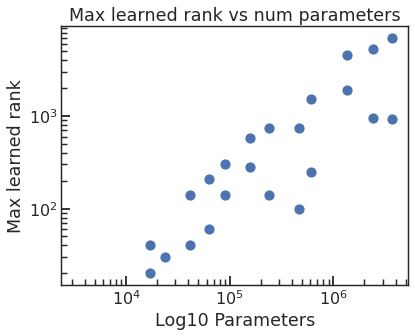

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/4141775270.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subresults["num_parameters"] = pd.to_numeric(subresults["num_parameters"])
/tmp/ipykernel_4157057/4141775270.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subresults["sequence_rank_plus_one"] = pd.to_numeric(subresults["sequence_rank_plus_one"])
/tmp/ipykernel_4157057/4141775270.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

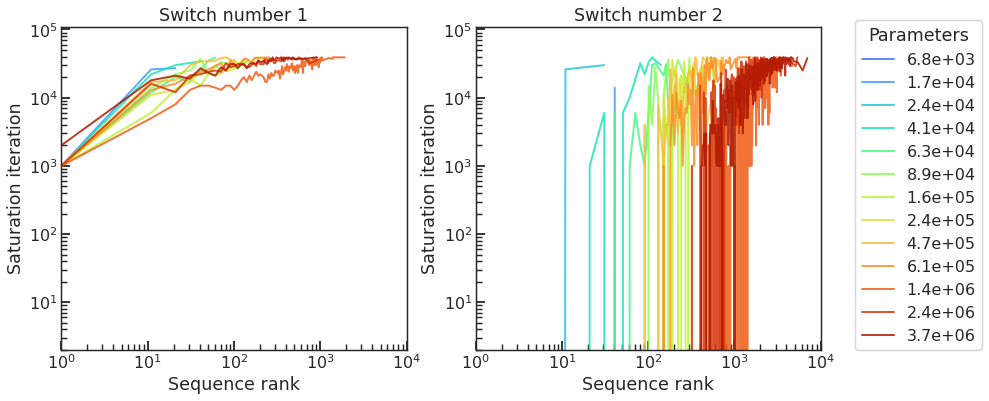

switch_number 1


/tmp/ipykernel_4157057/4141775270.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subresults["num_parameters"] = pd.to_numeric(subresults["num_parameters"])
/tmp/ipykernel_4157057/4141775270.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subresults["sequence_rank_plus_one"] = pd.to_numeric(subresults["sequence_rank_plus_one"])


,num_appearances,sequence_rank,accuracy,num_parameters,epoch,switch_number,iters,sequence_rank_plus_one
0,8195.0,0,0.949495,3354,1,1,1000.0,1
1,8349.0,0,0.949495,6758,1,1,1000.0,1
2,8229.0,0,0.989899,17022,1,1,1000.0,1
3,8271.0,0,1.000000,23882,1,1,1000.0,1
4,8352.0,0,0.979798,41058,1,1,1000.0,1
5,8288.0,0,1.000000,62842,1,1,1000.0,1
6,8331.0,0,0.919192,89234,1,1,1000.0,1
7,8493.0,0,1.000000,155842,1,1,1000.0,1
8,8312.0,0,1.000000,240882,1,1,1000.0,1
9,8345.0,0,0.989899,466258,1,1,1000.0,1


switch_number 2


/tmp/ipykernel_4157057/4141775270.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subresults["num_parameters"] = pd.to_numeric(subresults["num_parameters"])
/tmp/ipykernel_4157057/4141775270.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subresults["sequence_rank_plus_one"] = pd.to_numeric(subresults["sequence_rank_plus_one"])


,num_appearances,sequence_rank,accuracy,num_parameters,epoch,switch_number,iters,sequence_rank_plus_one
0,8164.0,0,0.929293,3354,40,2,0.0,1
1,8203.0,0,1.000000,6758,40,2,0.0,1
2,8339.0,0,1.000000,17022,40,2,0.0,1
3,8166.0,0,1.000000,23882,40,2,0.0,1
4,8218.0,0,0.989899,41058,40,2,0.0,1
5,8219.0,0,1.000000,62842,40,2,0.0,1
6,8300.0,0,1.000000,89234,40,2,0.0,1
7,8327.0,0,1.000000,155842,40,2,0.0,1
8,8292.0,0,1.000000,240882,40,2,0.0,1
9,8188.0,0,1.000000,466258,40,2,0.0,1


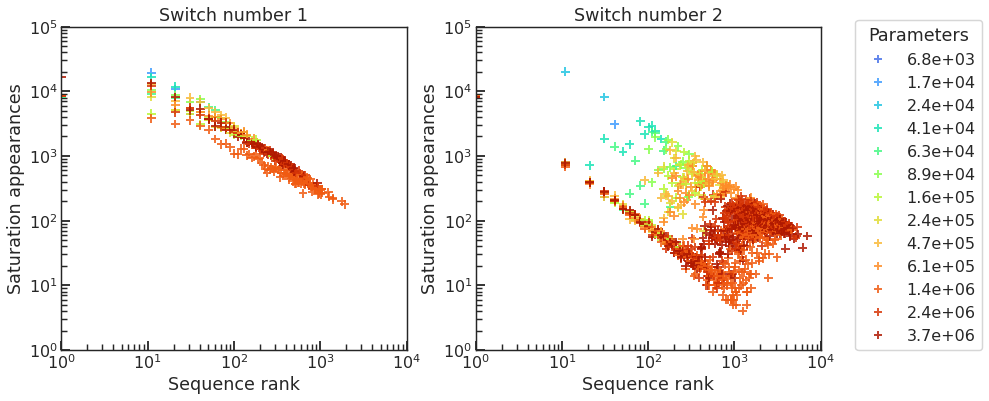

In [22]:
# plot the max rank at saturation vs num parameters
plt.scatter(df_capacity["num_parameters"], df_capacity["max_rank_at_saturation"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Log10 Parameters")
plt.ylabel("Max learned rank")
plt.title("Max learned rank vs num parameters")
plt.show()

# plot the saturation time vs sequence rank
def compute_saturation_time(row):
    time = row["epoch"] 
    if row["switch_number"] == 1:
        return time * 1000
    else:
        return (time - (row["switch_number"] - 1) * 40) * 1000

results["iters"] = results.apply(compute_saturation_time, axis=1)
results["sequence_rank_plus_one"] = results["sequence_rank"] + 1

# 2 significant figures for legend labels
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for i, switch_number in enumerate(results["switch_number"].unique()):
    subresults = results[results["switch_number"] == switch_number] 
    print("switch_number", switch_number)
    order = np.sort(subresults["num_parameters"].unique())
    pal = sns.color_palette("turbo", n_colors=len(order))
    subresults["num_parameters"] = pd.to_numeric(subresults["num_parameters"])
    subresults["sequence_rank_plus_one"] = pd.to_numeric(subresults["sequence_rank_plus_one"])

    sns.lineplot(
        data=subresults,
        x="sequence_rank_plus_one",
        y="iters",
        hue="num_parameters",           # <-- use formatted labels  
        hue_order=order,              # <-- numeric ascending -> consistent color order
        palette=pal,
        linewidth=2.0,
        alpha=0.85,
        legend=False if i == 0 else True,
        ax=axs[i]
    )
    axs[i].set_title(f"Switch number {switch_number}")
    axs[i].set_xscale("log")
    axs[i].set_xlim(1, 10000)
    axs[i].set_ylim(2, 110000)
    axs[i].set_yscale("log")
    axs[i].set_xlabel("Sequence rank")
    axs[i].set_ylabel("Saturation iteration")

handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(
    handles=handles[1:],
    labels=[f"{float(l):.2g}" for l in labels[1:]],
    title="Parameters",
    loc=(1.1, 0.0),
)
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for i, switch_number in enumerate(results["switch_number"].unique()):
    subresults = results[results["switch_number"] == switch_number]
    order = np.sort(subresults["num_parameters"].unique())
    pal = sns.color_palette("turbo", n_colors=len(order)) 
    subresults["num_parameters"] = pd.to_numeric(subresults["num_parameters"])
    subresults["sequence_rank_plus_one"] = pd.to_numeric(subresults["sequence_rank_plus_one"])

    subresults = subresults.sort_values(
        [ "sequence_rank_plus_one", "num_parameters"],
        ignore_index=True
    )
    print("switch_number", switch_number)
    display(subresults)
    pd.set_option('display.max_rows', 5000)
    sns.scatterplot(
        data=subresults,
        x="sequence_rank_plus_one",
        y="num_appearances",
        hue="num_parameters",
        hue_order=order,
        palette=pal,
        linewidth=2.0,
        alpha=0.85,
        legend=False if i == 0 else True,
        marker="+",
        ax=axs[i]
    )
    axs[i].set_title(f"Switch number {switch_number}")
    axs[i].set_xscale("log")
    axs[i].set_xlim(1, 10000)
    axs[i].set_ylim(1, 100000)
    axs[i].set_yscale("log")
    axs[i].set_xlabel("Sequence rank")
    axs[i].set_ylabel("Saturation appearances")

handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(
    handles=handles[1:],
    labels=[f"{float(l):.2g}" for l in labels[1:]],
    title="Parameters",
    loc=(1.1, 0.0),
)
plt.show()



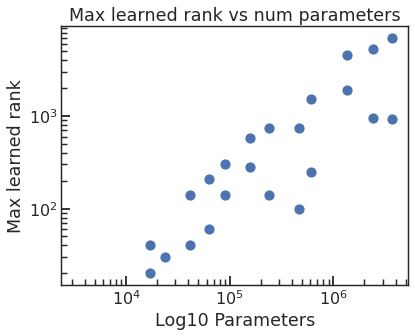

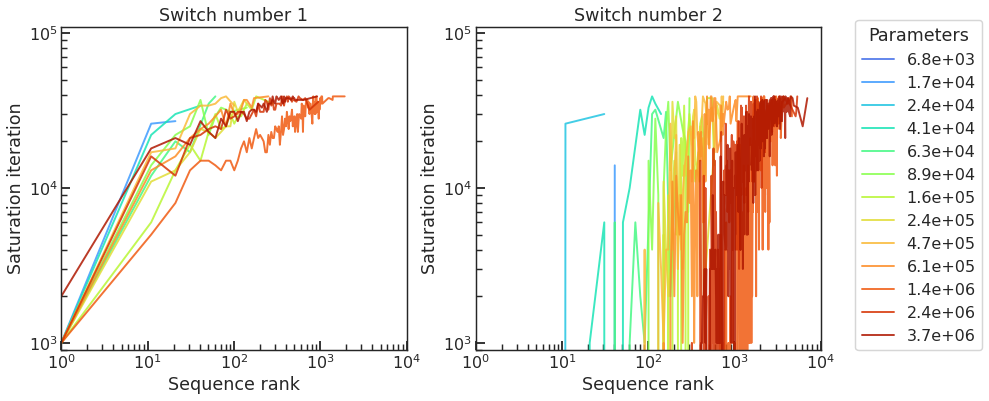

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


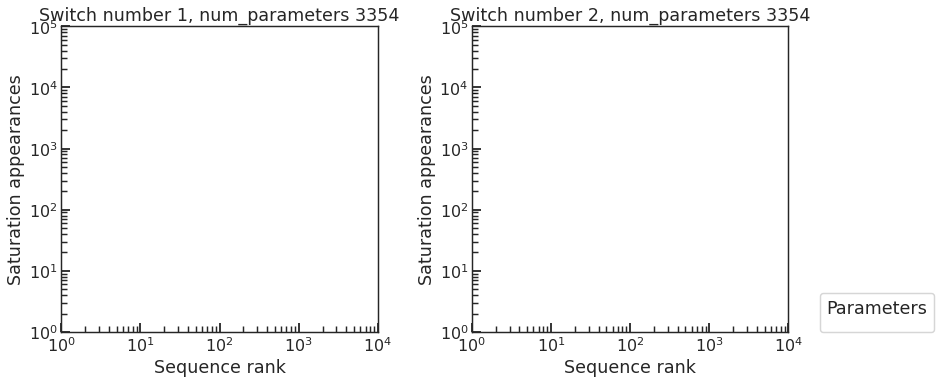

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


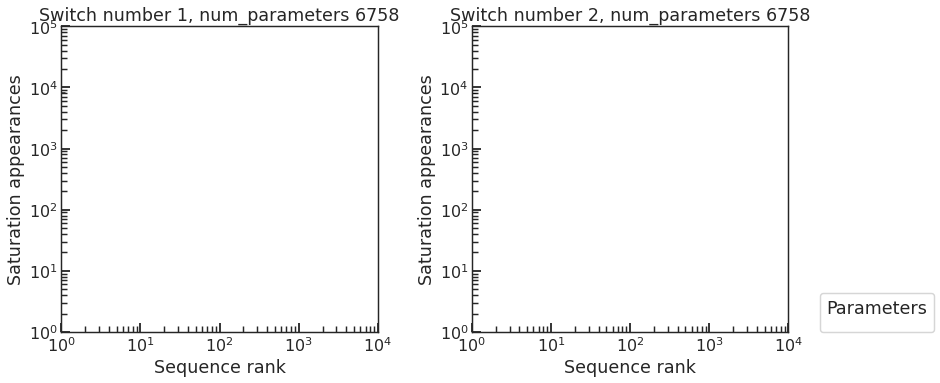

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


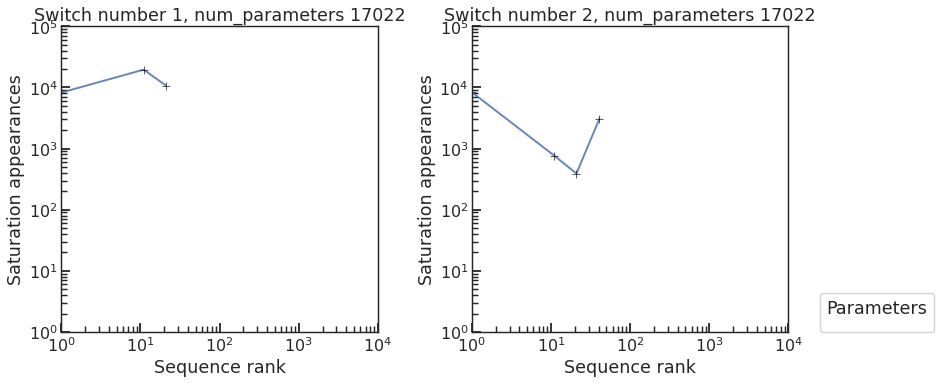

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


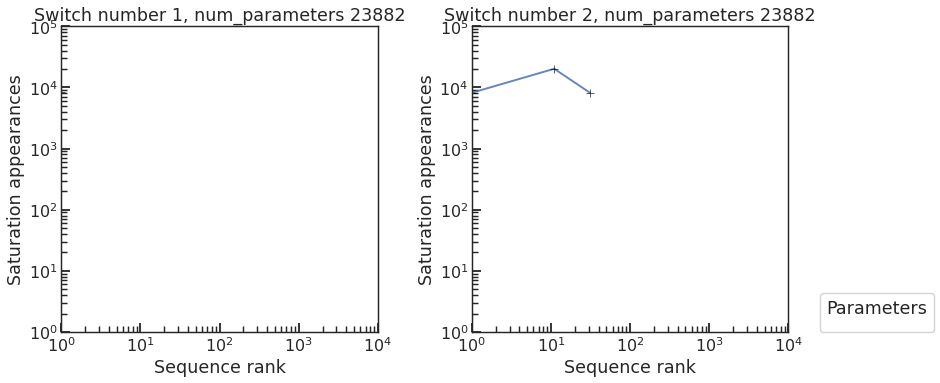

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


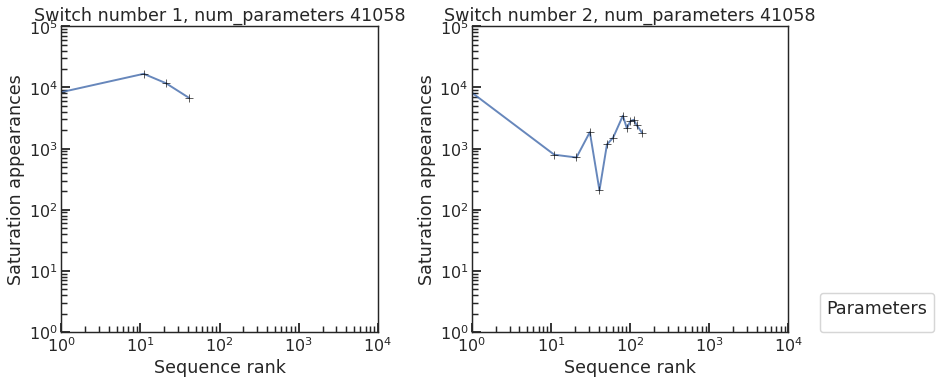

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


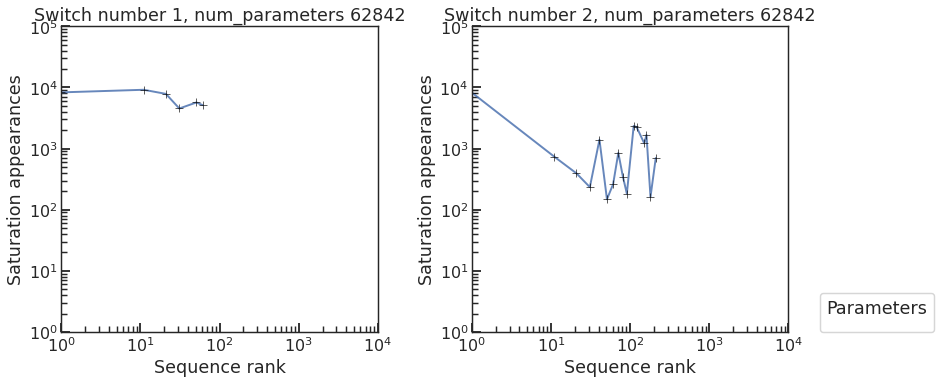

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


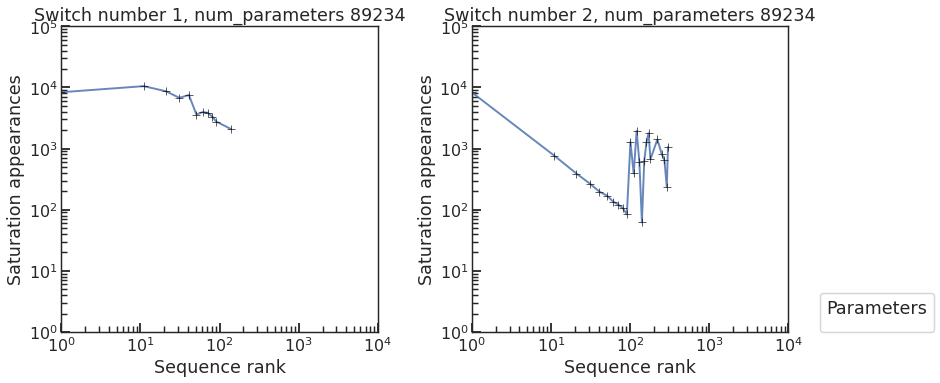

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


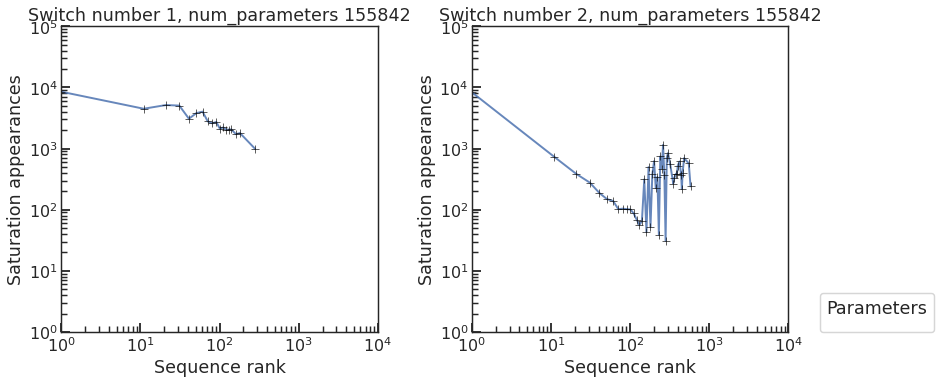

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


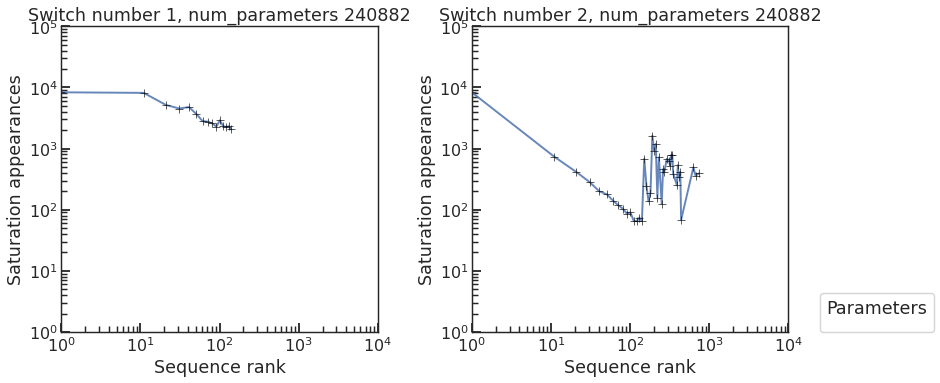

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


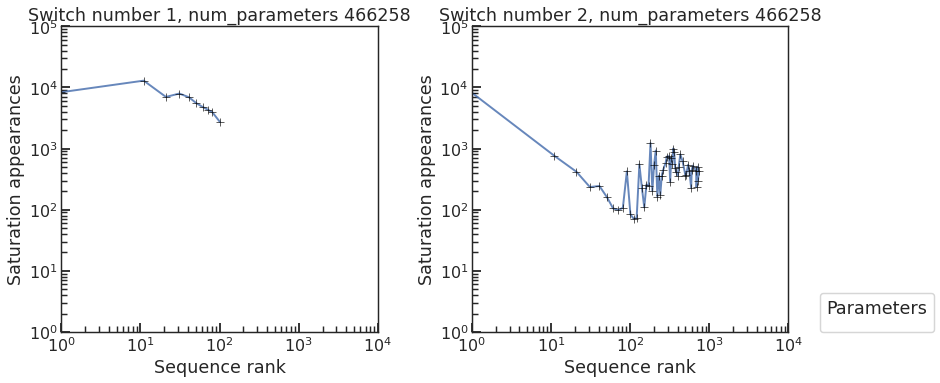

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


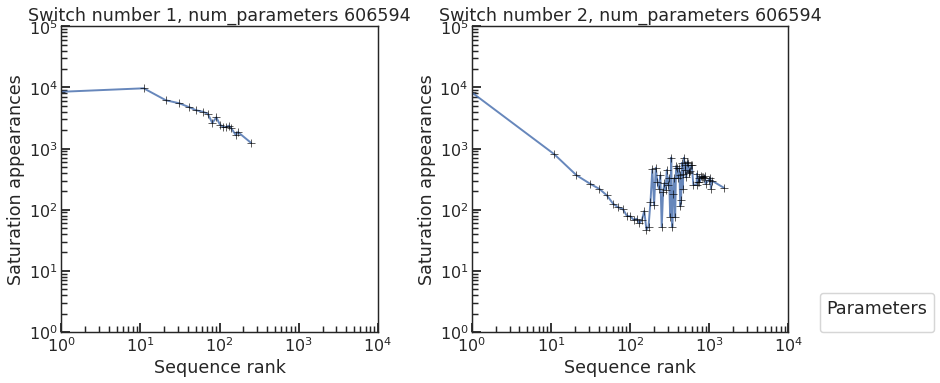

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


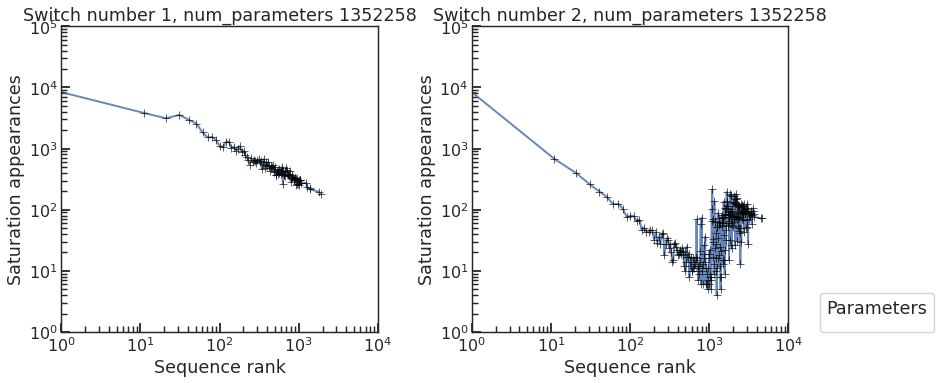

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


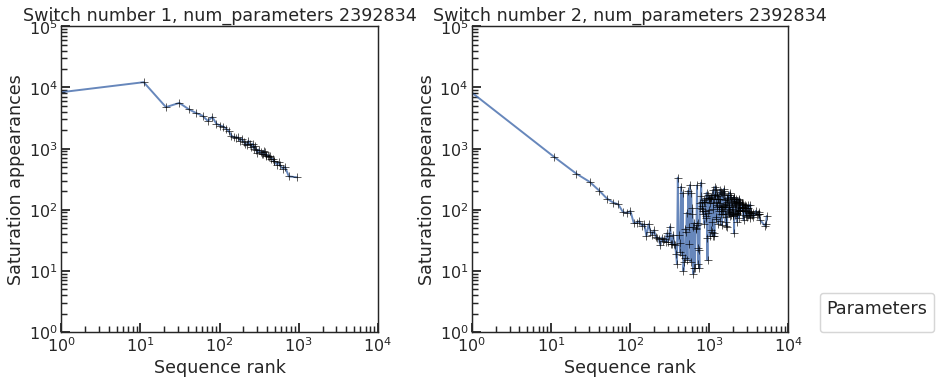

switch_number 1
switch_number 2


/tmp/ipykernel_4157057/2266335739.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(


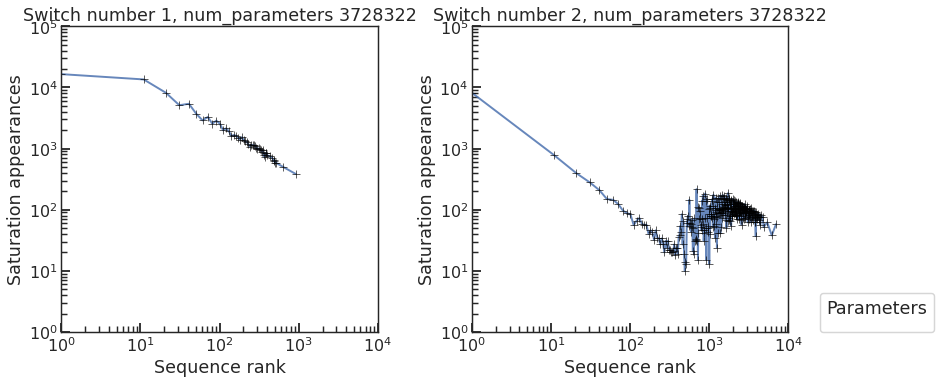

In [40]:
# plot the max rank at saturation vs num parameters
plt.scatter(df_capacity["num_parameters"], df_capacity["max_rank_at_saturation"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Log10 Parameters")
plt.ylabel("Max learned rank")
plt.title("Max learned rank vs num parameters")
plt.show()

# plot the saturation time vs sequence rank
def compute_saturation_time(row):
    time = row["epoch"] 
    if row["switch_number"] == 1:
        return time * 1000
    else:
        return (time - (row["switch_number"] - 1) * 40) * 1000

results["iters"] = results.apply(compute_saturation_time, axis=1)
results["sequence_rank_plus_one"] = results["sequence_rank"] + 1

# 2 significant figures for legend labels
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for i, switch_number in enumerate(results["switch_number"].unique()):
    subresults = results[results["switch_number"] == switch_number].copy()
    subresults["num_parameters"] = pd.to_numeric(subresults["num_parameters"])
    subresults["sequence_rank_plus_one"] = pd.to_numeric(subresults["sequence_rank_plus_one"])
    subresults = subresults.sort_values(
        ["num_parameters", "sequence_rank_plus_one"],
        ignore_index=True,
    )
    order = np.sort(subresults["num_parameters"].unique())
    pal = sns.color_palette("turbo", n_colors=len(order)) 
    sns.lineplot(
        data=subresults,
        x="sequence_rank_plus_one",
        y="iters",
        hue="num_parameters",           # <-- use formatted labels  
        hue_order=order,              # <-- numeric ascending -> consistent color order
        palette=pal,
        linewidth=2.0,
        alpha=0.85,
        legend=False if i == 0 else True,
        ax=axs[i]
    )
    axs[i].set_title(f"Switch number {switch_number}")
    axs[i].set_xscale("log")
    axs[i].set_xlim(1, 10000)
    axs[i].set_ylim(900, 110000)
    axs[i].set_yscale("log")
    axs[i].set_xlabel("Sequence rank")
    axs[i].set_ylabel("Saturation iteration")

handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(
    handles=handles[1:],
    labels=[f"{float(l):.2g}" for l in labels[1:]],
    title="Parameters",
    loc=(1.1, 0.0),
)
plt.show()



for _, num_parameters in enumerate(sorted(results["num_parameters"].unique())):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    
    for i, switch_number in enumerate(results["switch_number"].unique()):
        subresults = results[results["num_parameters"] == num_parameters]
        subresults = subresults[subresults["switch_number"] == switch_number]
        subresults["num_parameters"] = pd.to_numeric(subresults["num_parameters"])
        subresults["sequence_rank_plus_one"] = pd.to_numeric(subresults["sequence_rank_plus_one"])
        subresults = subresults.sort_values(
            ["num_parameters", "sequence_rank_plus_one"],
            ignore_index=True,
        )
        order = np.sort(subresults["num_parameters"].unique())
        # pal = sns.color_palette("coolwarm", n_colors=len(order)) 
        
        print("switch_number", switch_number)
        sns.lineplot(
            data=subresults,
            x="sequence_rank_plus_one",
            y="num_appearances",
            # hue="num_parameters",
            # hue_order=order,
            # palette=pal,
            linewidth=2.0,
            alpha=0.85,
            legend=False if i == 0 else True,
            marker="+", markeredgecolor="black",
            ax=axs[i]
        )
        axs[i].set_title(f"Switch number {switch_number}, num_parameters {num_parameters}")
        axs[i].set_xscale("log")
        axs[i].set_xlim(1, 10000)
        axs[i].set_ylim(1, 100000)
        axs[i].set_yscale("log")
        axs[i].set_xlabel("Sequence rank")
        axs[i].set_ylabel("Saturation appearances")

    handles, labels = axs[1].get_legend_handles_labels()
    axs[1].legend(
        handles=handles[1:],
        labels=[f"{float(l):.2g}" for l in labels[1:]],
        title="Parameters",
        loc=(1.1, 0.0),
    )
    out = f"./figs/number_appearances_at_saturation_vs_sequence_rank" 
    utils.ensure_dir(out)
    plt.tight_layout()
    plt.savefig(f"{out}/num_parameters_{num_parameters}.png") 
    plt.show()

